In [28]:
from ms_lib import *

R0 = 10e3 
beta = 3950
R = 1.5e3
T0 = 298

def f(T):
    return R - R0*exp( beta*(1/T - 1/T0) )

def fp(T):
    return beta*R0/(T**2)*exp( beta*(1/T - 1/T0) ) 

In [29]:
f(298), fp(298)

(-8500.0, 444.7997837935228)

In [68]:
T = 298

T_iter = []

for k in range(5):
    T_iter += [T]
    T_next = T - f(T)/fp(T)
    print(f"{k+0} {T:.1f} {f(T)/1e3:.2f} {fp(T)/1e3:.3f}")
    T = T_next

0 298.0 -8.50 0.445
1 317.1 -3.00 0.177
2 334.1 -0.89 0.085
3 344.6 -0.17 0.055
4 347.6 -0.01 0.049


In [69]:
f(301.699)

-7000.040271212551

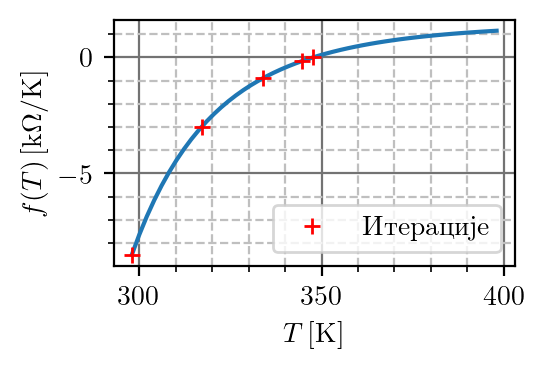

In [70]:
generate_canvas()
T_vec = np.linspace(T0, T0+100)
f_vec = np.array([f(T) for T in T_vec])
f_iter = np.array([f(T) for T in T_iter])

plt.plot(T_vec, f_vec/1000)
plt.plot(T_iter, f_iter/1000, 'r+', label="Итерације")
plt.xlabel(r"$T\rm\,[K]$")
plt.ylabel(r"$f(T)\rm\,[k\Omega/K]$")
plt.legend()
plt.savefig("nr_iter.pdf", bbox_inches = 'tight')